# Hierarchical Demand Forecasting: walkthrough

This notebook reads the **gold tables** written by `python -m forecasting.pipeline` and walks through the results in pipeline order:
1. Model comparison
2. Reconciliation
3. Calibrated intervals
4. Constrained allocation
5. Drift

It doesn't train anything. Rerun the pipeline to refresh the numbers.

**Evaluation design.** There are three 28-day rolling-origin backtest folds. They are followed by a **holdout** fold on the M5 validation window (2016-04-25 → 2016-05-22), which is never used for model selection. The production forecast covers the next 28 days (2016-05-23 → 2016-06-19).

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

GOLD = Path.cwd().parent / "data" / "gold" if Path.cwd().name == "notebooks" else Path("data/gold")
summary = json.loads((GOLD / "run_summary.json").read_text())
read = lambda name: pd.read_parquet(GOLD / f"{name}.parquet")

# Reference palette, fixed slot order; ink colours for text and actuals.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.figsize": (9, 3.6), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True, "lines.linewidth": 2,
    "legend.frameon": False, "font.size": 10,
})

def date_axis(ax):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
pd.set_option("display.precision", 3)
{key: summary[key] for key in ("n_series", "selected_bottom_model", "origins", "timings_seconds")}

{'n_series': 12196,
 'selected_bottom_model': 'lgbm_global',
 'origins': {'backtest_1': '2016-01-31',
  'backtest_2': '2016-02-28',
  'backtest_3': '2016-03-27',
  'holdout': '2016-04-24',
  'production': '2016-05-22'},
 'timings_seconds': {'load_and_features': 25.0,
  'models_backtest_1': 203.2,
  'models_backtest_2': 183.8,
  'models_backtest_3': 206.2,
  'models_holdout': 207.5,
  'models_production': 90.4,
  'total': 919.4}}

## 1. Models

Every bottom-level model is aggregated bottom-up, so it can be compared at each level. SARIMA and Prophet forecast the aggregate series directly. The numbers are mean WMAPE across the three backtest folds plus the holdout.

In [2]:
models = read("model_metrics")
table = models.pivot_table(index="model", columns="level", values="wmape", aggfunc="mean")
table[["item", "department", "category", "store", "state", "total"]].sort_values("item")

level,item,department,category,store,state,total
model,,,,,,
lgbm_global,0.741,0.113,0.097,0.082,0.065,0.065
lgbm_local,0.743,0.128,0.114,0.100,0.082,0.082
seasonal_naive,0.888,0.121,0.098,0.078,0.067,0.067
naive,1.037,0.324,0.308,0.298,0.290,0.290
prophet,NaN,NaN,NaN,0.067,0.056,0.056
sarima,NaN,0.098,0.078,0.064,0.052,0.052


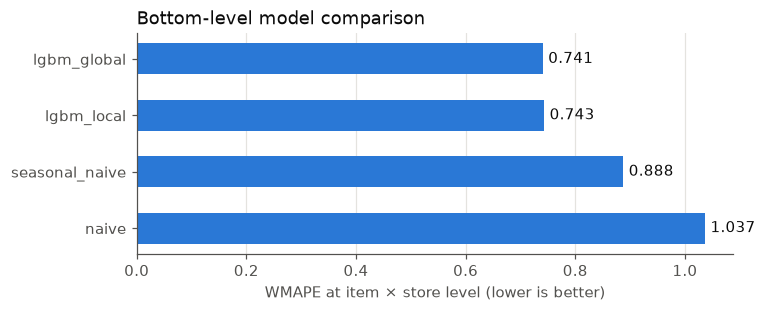

In [3]:
item = models[models["level"] == "item"].groupby("model")["wmape"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(item.index, item.values, color=SERIES[0], height=0.55)
for y, value in enumerate(item.values):
    ax.text(value + 0.01, y, f"{value:.3f}", va="center", color=INK)
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlabel("WMAPE at item × store level (lower is better)")
ax.set_title("Bottom-level model comparison", loc="left", color=INK)
plt.show()

## 2. Reconciliation

The inputs are the base forecasts: SARIMA for the 46 aggregate nodes and the selected LightGBM model for the 12,196 items. These are incoherent, so the aggregates don't add up.
* **Bottom-up** sums the item forecasts.
* **Top-down** splits the SARIMA total by historical proportions.
* **MinT (diagonal)** projects every level onto the coherent subspace, weighting each node by its **in-sample** residual variance.
* **MinT (out-of-sample)** does the same, but weights by each base model's squared error in the **previous** 28-day window. The folds are contiguous, so that is exactly the out-of-sample window before each origin.

Both MinT variants are solved with the Woodbury identity, so the only matrix they invert is 46×46. The **served** method is the coherent method with the best WRMSSE on the backtest folds; the holdout is never used for the choice.

In [4]:
recon = read("reconciliation_metrics")
METHODS = ["base", "bottom_up", "top_down", "mint_diagonal", "mint_oos"]
LEVELS = ["total", "state", "store", "category", "department", "item"]
print("Served method:", summary["served_method"])
holdout = recon[recon["fold"] == "holdout"]
holdout.pivot_table(index="level", columns="method", values="wmape").loc[LEVELS, METHODS]

Served method: mint_diagonal


method,base,bottom_up,top_down,mint_diagonal,mint_oos
level,,,,,
total,0.046,0.069,0.046,0.064,0.059
state,0.046,0.069,0.046,0.064,0.059
store,0.058,0.086,0.087,0.079,0.072
category,0.069,0.099,0.096,0.090,0.083
department,0.086,0.113,0.115,0.105,0.099
item,0.727,0.727,0.750,0.727,0.727


**WRMSSE** is the official M5 metric. Each node's RMSE is scaled by its in-sample one-step naive error, weighted by its recent revenue, and every level counts equally. Below it's the holdout, per level and averaged over the six levels.

In [5]:
wrmsse = holdout.pivot_table(index="level", columns="method", values="wrmsse").loc[LEVELS, METHODS]
wrmsse.loc["mean (M5-style)"] = wrmsse.mean()
wrmsse

method,base,bottom_up,top_down,mint_diagonal,mint_oos
level,,,,,
total,0.362,0.512,0.362,0.457,0.417
state,0.362,0.512,0.362,0.457,0.417
store,0.424,0.571,0.632,0.520,0.486
category,0.466,0.596,0.644,0.550,0.518
department,0.531,0.639,0.706,0.600,0.574
item,0.809,0.809,0.825,0.807,0.806
mean (M5-style),0.492,0.607,0.589,0.565,0.536


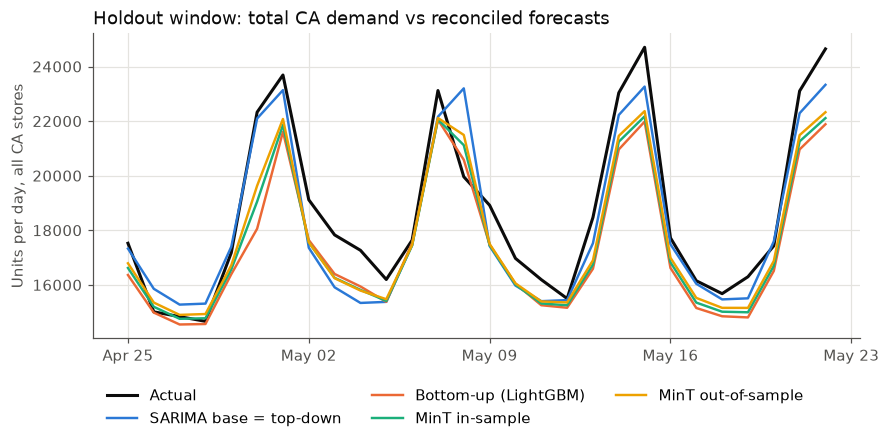

In [6]:
bf = read("backtest_forecasts")
total = bf[(bf["level"] == "total") & (bf["fold"] == "holdout")]
fig, ax = plt.subplots()
actual = total[total["method"] == "base"]
ax.plot(actual["date"], actual["actual"], color=INK, label="Actual")
# At the total node, top-down equals the SARIMA base forecast, so one line covers both.
for colour, (method, label) in zip(SERIES, [("base", "SARIMA base = top-down"), ("bottom_up", "Bottom-up (LightGBM)"), ("mint_diagonal", "MinT in-sample"), ("mint_oos", "MinT out-of-sample")]):
    rows = total[total["method"] == method]
    ax.plot(rows["date"], rows["forecast"], color=colour, label=label, linewidth=1.6)
date_axis(ax)
ax.set_ylabel("Units per day, all CA stores")
ax.set_title("Holdout window: total CA demand vs reconciled forecasts", loc="left", color=INK)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.12))
plt.show()

## 3. Prediction intervals

The intervals are split-conformal. Scores are signed and scale-normalised, and each fold is calibrated **only on earlier folds**, so the coverage below is out-of-sample.

In [7]:
coverage = read("interval_coverage")
coverage.pivot_table(index="level", columns="nominal", values=["coverage", "mean_width"])

coverage        mean_width          
nominal        0.80   0.95       0.80      0.95
level                                          
category      0.782  0.938    344.069   573.328
department    0.769  0.942    179.759   306.392
item          0.804  0.953      3.297     7.563
state         0.786  0.929   2093.153  4590.894
store         0.738  0.926    789.520  1361.003
total         0.786  0.929   2093.153  4590.894

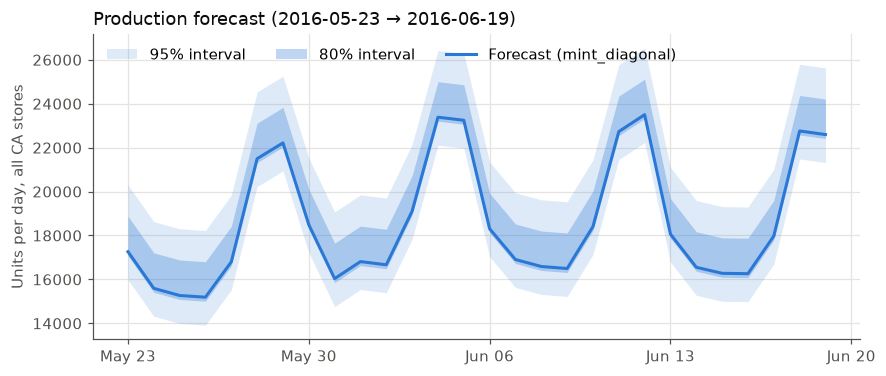

In [8]:
intervals = read("prediction_intervals")
node = intervals[intervals["series_id"] == "total:total"]
fig, ax = plt.subplots()
ax.fill_between(node["date"], node["lower_95"], node["upper_95"], color=SERIES[0], alpha=0.15, linewidth=0, label="95% interval")
ax.fill_between(node["date"], node["lower_80"], node["upper_80"], color=SERIES[0], alpha=0.30, linewidth=0, label="80% interval")
ax.plot(node["date"], node["forecast"], color=SERIES[0], label=f"Forecast ({summary['served_method']})")
date_axis(ax)
ax.set_ylabel("Units per day, all CA stores")
ax.set_title("Production forecast (2016-05-23 → 2016-06-19)", loc="left", color=INK)
ax.legend(loc="upper left", ncol=3)
plt.show()

## 4. Constrained allocation

Each week, a distribution centre holds only 90% of the forecast demand for the 28 store × department nodes. A scenario LP (a newsvendor-style expected-fulfilment objective weighted by unit revenue) competes against a pro-rata split. Both are scored on **realised** demand in the folds that have earlier calibration data.

In [9]:
alloc = read("allocation_backtest")
by_policy = alloc.groupby("policy")[["units_fulfilled", "units_demanded", "revenue_fulfilled", "stockout_nodes"]].sum()
by_policy["fill_rate"] = by_policy["units_fulfilled"] / by_policy["units_demanded"]
uplift = by_policy.loc["lp_scenario", "revenue_fulfilled"] / by_policy.loc["pro_rata", "revenue_fulfilled"] - 1
print(f"LP revenue fulfilled vs pro-rata: {uplift:+.2%} over {alloc[['fold', 'week']].drop_duplicates().shape[0]} weekly allocations")
by_policy

LP revenue fulfilled vs pro-rata: +1.57% over 12 weekly allocations


,units_fulfilled,units_demanded,revenue_fulfilled,stockout_nodes,fill_rate
policy,,,,,
lp_scenario,1.296e+06,1.520e+06,4.412e+06,255,0.853
pro_rata,1.308e+06,1.520e+06,4.344e+06,308,0.861


In [10]:
read("allocation")[["dept_id", "store_id", "forecast", "allocated_quantity", "pro_rata_quantity", "stockout_risk", "safety_stock"]].sort_values(["store_id", "dept_id"]).head(14)

,dept_id,store_id,forecast,allocated_quantity,pro_rata_quantity,stockout_risk,safety_stock
0,FOODS_1,CA_1,2328.562,2046.003,2095.706,0.92,519.163
4,FOODS_2,CA_1,3654.430,3620.342,3288.987,0.64,891.991
8,FOODS_3,CA_1,14891.183,11589.090,13402.064,0.96,3764.582
12,HOBBIES_1,CA_1,3428.990,3505.581,3086.091,0.52,827.110
16,HOBBIES_2,CA_1,316.376,0.000,284.738,1.00,71.133
20,HOUSEHOLD_1,CA_1,5465.283,5469.592,4918.754,0.60,1274.934
24,HOUSEHOLD_2,CA_1,1615.200,1670.429,1453.680,0.48,377.399
1,FOODS_1,CA_2,3282.665,3060.978,2954.399,0.84,802.249
5,FOODS_2,CA_2,3449.304,3385.963,3104.374,0.68,868.929
9,FOODS_3,CA_2,13055.231,11253.028,11749.708,0.92,3311.302


## 5. Drift and retraining

Drift uses two PSI signals per store. The first is demand-mix PSI, which compares item-level log sales in the last 28 days with the previous year. The second is residual PSI, which compares holdout errors with backtest errors. The retraining flag also fires if store-level WMAPE degrades by more than 10%.

In [11]:
read("drift")

,node_id,demand_psi,residual_psi,reference_mean_daily,current_mean_daily,psi,drift,retrain,retrain_reasons
0,store:store_id=CA_1,0.009,0.009,4436.044,4786.857,0.009,False,False,stable
1,store:store_id=CA_2,0.031,0.010,3885.038,4747.143,0.031,False,False,stable
2,store:store_id=CA_3,0.008,0.004,6286.758,6262.857,0.008,False,False,stable
3,store:store_id=CA_4,0.012,0.012,2466.813,2816.357,0.012,False,False,stable
